#  Notebook 2: Content-Based Filtering

Two text representations are built and compared:
1. **TF-IDF** vectorisation + Cosine Similarity
2. **Bag-of-Words (BoW)** vectorisation + Cosine Similarity

For each representation we build a content-based recommender and compute evaluation metrics.

In [1]:
from pathlib import Path

# ── Paths ────────────────────────────────────────────
DATA_DIR    = Path('data/processed')
FIGURES_DIR = Path('figures/content_based')
MODELS_DIR  = Path('models/content_based')
RESULTS_DIR = Path('results')

for _dir in [FIGURES_DIR, MODELS_DIR, RESULTS_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

# Load final cleaned dataset after merge + normalization + predicted unrated courses
dataset = pd.read_csv(DATA_DIR / 'final_merged_dataset.csv')

# Remove duplicate column names just in case
dataset = dataset.loc[:, ~dataset.columns.duplicated()]

print("Dataset shape:", dataset.shape)
print(dataset.head())

Dataset shape: (233306, 19)
    COURSE_ID                          TITLE  Database  Python  \
0    CC0101EN          introduction to cloud         0       0   
1    CL0101EN           ibm cloud essentials         0       0   
2  ML0120ENv3  deep learning with tensorflow         0       0   
3    BD0211EN           spark fundamentals i         1       0   
4    DS0101EN   introduction to data science         0       0   

   CloudComputing  DataAnalysis  Containers  MachineLearning  ComputerVision  \
0               1             0           0                0               0   
1               1             0           0                0               0   
2               0             0           0                1               0   
3               0             1           0                0               0   
4               0             0           0                0               0   

   DataScience  BigData  Chatbot  R  BackendDev  FrontendDev  Blockchain  \
0            0    

In [2]:
# Genre columns
genre_cols = [
    'Database', 'Python', 'CloudComputing', 'DataAnalysis', 'Containers',
    'MachineLearning', 'ComputerVision', 'DataScience', 'BigData',
    'Chatbot', 'R', 'BackendDev', 'FrontendDev', 'Blockchain'
]

# Unique course table for content-based features
courses = dataset.drop_duplicates(subset=['COURSE_ID']).copy()

# Ratings table for user interactions
ratings = dataset[['user', 'COURSE_ID', 'rating']].copy()

print("Unique courses:", courses.shape)
print("Ratings shape :", ratings.shape)

Unique courses: (126, 19)
Ratings shape : (233306, 3)


## 1. Load & Prepare Data

In [3]:
def build_course_text(row):
    title = str(row['TITLE']).strip().lower()
    tags = ' '.join([col.lower() for col in genre_cols if row[col] == 1])
    return f"{title} {tags}".strip()

courses['doc'] = courses.apply(build_course_text, axis=1)

print(courses[['COURSE_ID', 'TITLE', 'doc']].head(5).to_string())

    COURSE_ID                          TITLE                                                 doc
0    CC0101EN          introduction to cloud                introduction to cloud cloudcomputing
1    CL0101EN           ibm cloud essentials                 ibm cloud essentials cloudcomputing
2  ML0120ENv3  deep learning with tensorflow       deep learning with tensorflow machinelearning
3    BD0211EN           spark fundamentals i  spark fundamentals i database dataanalysis bigdata
4    DS0101EN   introduction to data science            introduction to data science datascience


## 2. TF-IDF Vectorisation

In [4]:
tfidf_vec = TfidfVectorizer(
    stop_words='english',
    max_features=500,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vec.fit_transform(courses['doc'])

print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"Vocabulary size     : {len(tfidf_vec.vocabulary_)}")

TF-IDF matrix shape : (126, 500)
Vocabulary size     : 500


In [5]:
tfidf_cos = cosine_similarity(tfidf_matrix)

tfidf_cos_df = pd.DataFrame(
    tfidf_cos,
    index=courses['COURSE_ID'],
    columns=courses['COURSE_ID']
)

print("TF-IDF cosine similarity matrix (5x5 sample):")
print(tfidf_cos_df.iloc[:5, :5].round(4))

TF-IDF cosine similarity matrix (5x5 sample):
COURSE_ID   CC0101EN  CL0101EN  ML0120ENv3  BD0211EN  DS0101EN
COURSE_ID                                                     
CC0101EN      1.0000    0.2614         0.0       0.0    0.2305
CL0101EN      0.2614    1.0000         0.0       0.0    0.0000
ML0120ENv3    0.0000    0.0000         1.0       0.0    0.0000
BD0211EN      0.0000    0.0000         0.0       1.0    0.0000
DS0101EN      0.2305    0.0000         0.0       0.0    1.0000


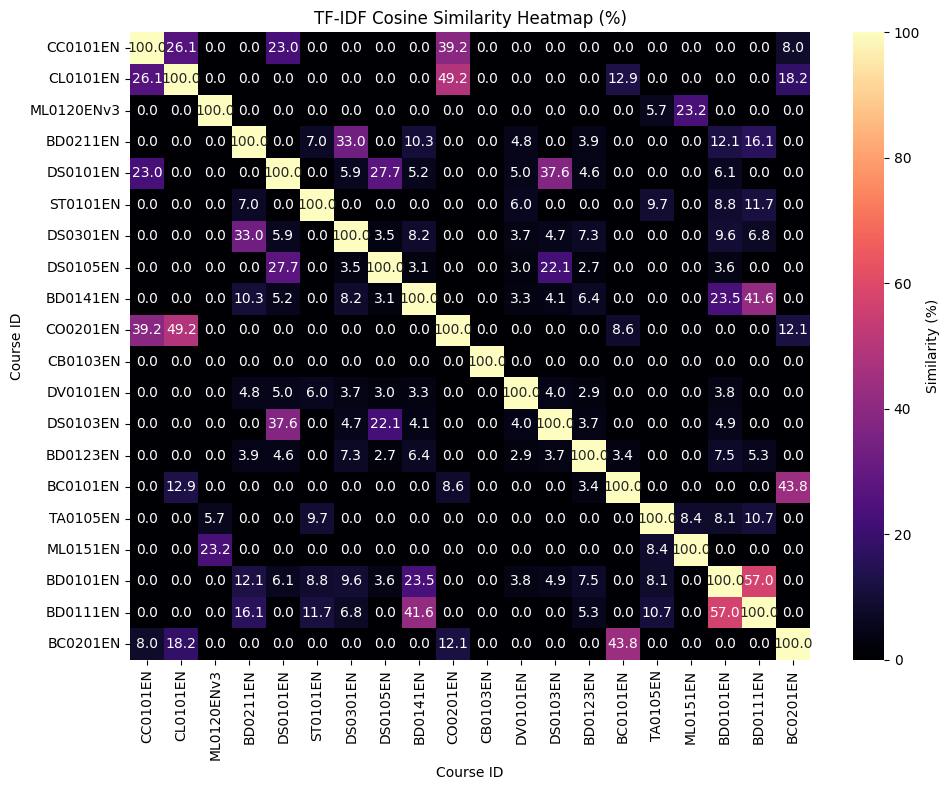

In [6]:
tfidf_percent = tfidf_cos_df * 100
tfidf_sample = tfidf_percent.iloc[:20, :20]

plt.figure(figsize=(10, 8))
sns.heatmap(
    tfidf_sample,
    cmap="magma",
    annot=True,
    fmt=".1f",
    cbar_kws={'label': 'Similarity (%)'}
)
plt.title("TF-IDF Cosine Similarity Heatmap (%)")
plt.xlabel("Course ID")
plt.ylabel("Course ID")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tfidf_cosine_similarity_percentage.png", dpi=300, bbox_inches='tight')
plt.show()

## 3. Bag-of-Words Vectorisation

In [7]:
bow_vec = CountVectorizer(
    stop_words='english',
    max_features=500,
    ngram_range=(1, 2)
)

bow_matrix = bow_vec.fit_transform(courses['doc'])

print(f"BoW matrix shape    : {bow_matrix.shape}")
print(f"Vocabulary size     : {len(bow_vec.vocabulary_)}")

bow_cos = cosine_similarity(bow_matrix)

bow_cos_df = pd.DataFrame(
    bow_cos,
    index=courses['COURSE_ID'],
    columns=courses['COURSE_ID']
)

print("BoW cosine similarity matrix (5x5 sample):")
print(bow_cos_df.iloc[:5, :5].round(4))

BoW matrix shape    : (126, 500)
Vocabulary size     : 500
BoW cosine similarity matrix (5x5 sample):
COURSE_ID   CC0101EN  CL0101EN  ML0120ENv3  BD0211EN  DS0101EN
COURSE_ID                                                     
CC0101EN      1.0000    0.4082         0.0       0.0    0.2041
CL0101EN      0.4082    1.0000         0.0       0.0    0.0000
ML0120ENv3    0.0000    0.0000         1.0       0.0    0.0000
BD0211EN      0.0000    0.0000         0.0       1.0    0.0000
DS0101EN      0.2041    0.0000         0.0       0.0    1.0000


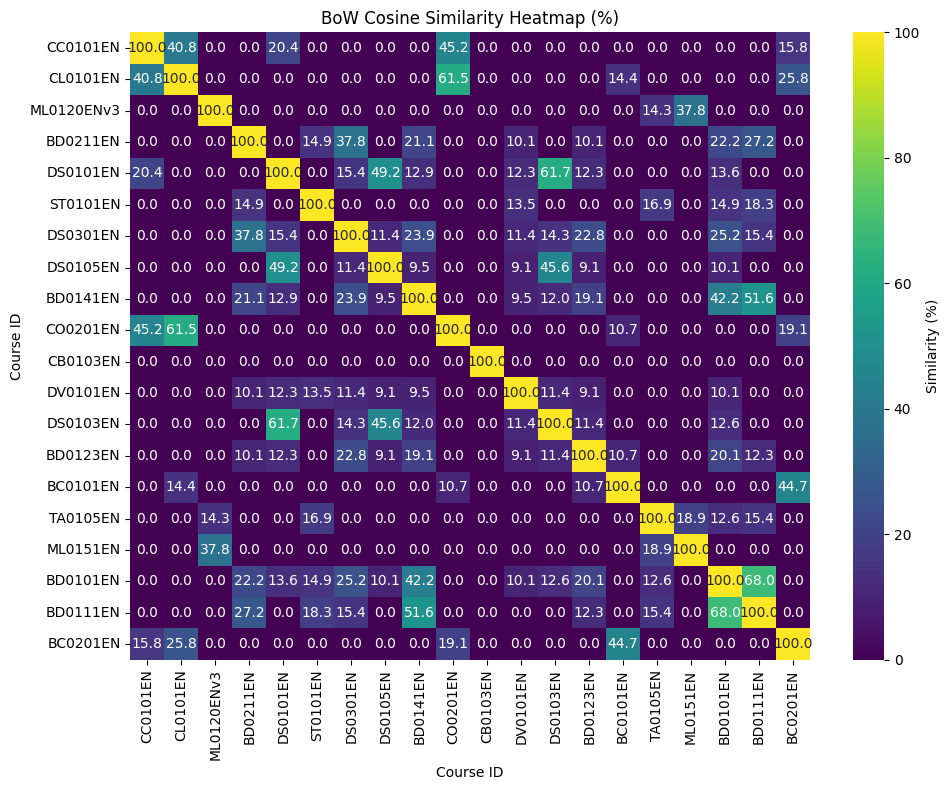

In [8]:
bow_percent = bow_cos_df * 100
bow_sample = bow_percent.iloc[:20, :20]

plt.figure(figsize=(10, 8))
sns.heatmap(
    bow_sample,
    cmap="viridis",
    annot=True,
    fmt=".1f",
    cbar_kws={'label': 'Similarity (%)'}
)
plt.title("BoW Cosine Similarity Heatmap (%)")
plt.xlabel("Course ID")
plt.ylabel("Course ID")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bow_cosine_similarity_percentage.png", dpi=300, bbox_inches='tight')
plt.show()

## 4. Recommendation Function

In [9]:
def get_content_recommendations(course_id, sim_df, top_n=10, exclude_self=True):
    if course_id not in sim_df.index:
        return pd.Series(dtype=float)

    scores = sim_df.loc[course_id].copy()

    if exclude_self:
        scores = scores.drop(index=course_id, errors='ignore')

    return scores.sort_values(ascending=False).head(top_n)

## 4. Recommendation Function - DEMO 

In [10]:
sample_course = courses['COURSE_ID'].iloc[0]
sample_title = courses.loc[courses['COURSE_ID'] == sample_course, 'TITLE'].iloc[0]

print(f"Course: {sample_course} — {sample_title}")

print("\n── TF-IDF Top-10 ──")
rec_tfidf = get_content_recommendations(sample_course, tfidf_cos_df)
for cid, score in rec_tfidf.items():
    title = courses.loc[courses['COURSE_ID'] == cid, 'TITLE'].iloc[0]
    print(f"{cid:20s} {score:.4f}  {title}")

print("\n── BoW Top-10 ──")
rec_bow = get_content_recommendations(sample_course, bow_cos_df)
for cid, score in rec_bow.items():
    title = courses.loc[courses['COURSE_ID'] == cid, 'TITLE'].iloc[0]
    print(f"{cid:20s} {score:.4f}  {title}")

Course: CC0101EN — introduction to cloud

── TF-IDF Top-10 ──
CO0201EN             0.3924  container   kubernetes essentials with ibm cloud
CL0101EN             0.2614  ibm cloud essentials
DS0101EN             0.2305  introduction to data science
CC0103EN             0.2057  ibm cloud essentials   v3
CO0101EN             0.2054  docker essentials  a developer introduction
CC0271EN             0.2019  cloud pak for integration essentials
HCC104EN             0.1820  hybrid cloud conference serverless lab
DW0101EN             0.1799  introduction to machine learning with sound
CC0250EN             0.1697  building cloud native and multicloud applications
CC0210EN             0.1545  serverless computing using cloud functions   developer i

── BoW Top-10 ──
CO0201EN             0.4523  container   kubernetes essentials with ibm cloud
CL0101EN             0.4082  ibm cloud essentials
CC0103EN             0.3536  ibm cloud essentials   v3
CC0271EN             0.3536  cloud pak for integrat

## 5. Profile-based Recommendations (User History)

In [11]:
def user_content_recs(user_id, ratings_df, sim_df, top_n=10):
    seen = ratings_df.loc[ratings_df['user'] == user_id, 'COURSE_ID'].tolist()
    seen = [c for c in seen if c in sim_df.index]

    if not seen:
        return pd.Series(dtype=float)

    profile = sim_df.loc[seen].mean(axis=0)
    profile = profile.drop(index=seen, errors='ignore')

    return profile.sort_values(ascending=False).head(top_n)

In [12]:
active_users = ratings.groupby('user').size()
active_users = active_users[active_users >= 5].index

sample_user = active_users[0]
print(f"Sample user: {sample_user}")

print("\nTF-IDF recs:")
print(user_content_recs(sample_user, ratings, tfidf_cos_df))

print("\nBoW recs:")
print(user_content_recs(sample_user, ratings, bow_cos_df))

Sample user: 2

TF-IDF recs:
COURSE_ID
DB0151EN      0.080086
TA0105EN      0.078157
TMP107        0.063042
DA0151EN      0.062502
ML0120ENv3    0.061202
DS0101EN      0.059787
ML0122ENv3    0.058062
ML0101ENv3    0.057923
BD0115EN      0.052370
DS0110EN      0.044404
dtype: float64

BoW recs:
COURSE_ID
DB0151EN      0.135776
DA0151EN      0.116164
BD0115EN      0.103364
TA0105EN      0.102711
DS0101EN      0.096539
DS0110EN      0.094629
TMP107        0.092869
DA0201EN      0.087993
ML0120ENv3    0.077480
DS0201EN      0.076840
dtype: float64


## 6. Evaluation Metrics

In [13]:
def evaluate_content_model(sim_df, ratings_df, courses_df, top_n=10, n_users=200, seed=42):
    rng = np.random.default_rng(seed)

    user_counts = ratings_df['user'].value_counts()
    eligible_users = user_counts[user_counts >= 5].index.tolist()

    if len(eligible_users) == 0:
        raise ValueError("No users with at least 5 ratings found.")

    sampled_users = rng.choice(eligible_users, size=min(n_users, len(eligible_users)), replace=False)

    all_courses = set(sim_df.index)

    hit_list = []
    prec_list = []
    rec_list = []
    ndcg_list = []
    sq_errors = []
    abs_errors = []
    recommended_set = set()

    for u in sampled_users:
        u_df = ratings_df[ratings_df['user'] == u].copy()

        if len(u_df) < 5:
            continue

        train_df, test_df = train_test_split(u_df, test_size=0.2, random_state=seed)

        train_items = train_df['COURSE_ID'].tolist()
        test_items = set(test_df['COURSE_ID'].tolist())

        seen = [c for c in train_items if c in sim_df.index]
        if not seen:
            continue

        # Build profile from training items only
        profile = sim_df.loc[seen].mean(axis=0)
        profile = profile.drop(index=seen, errors='ignore')
        recs = profile.sort_values(ascending=False).head(top_n)

        if recs.empty:
            continue

        rec_ids = set(recs.index)
        recommended_set.update(rec_ids)

        hits = rec_ids & test_items
        hit_list.append(1 if len(hits) > 0 else 0)
        prec_list.append(len(hits) / top_n)
        rec_list.append(len(hits) / len(test_items) if len(test_items) > 0 else 0)

        # NDCG
        dcg = 0.0
        ideal = 0.0
        for rank, item in enumerate(recs.index, start=1):
            rel = 1 if item in test_items else 0
            dcg += rel / np.log2(rank + 1)

        for rank in range(1, min(len(test_items), top_n) + 1):
            ideal += 1 / np.log2(rank + 1)

        ndcg_list.append(dcg / ideal if ideal > 0 else 0)

        # Approximate rating prediction for overlapping recommended test items
        test_ratings = test_df.set_index('COURSE_ID')['rating']
        for item in hits:
            pred = float(recs.loc[item]) * 3.0
            actual = float(test_ratings.loc[item])
            sq_errors.append((pred - actual) ** 2)
            abs_errors.append(abs(pred - actual))

    # Diversity
    all_recs = list(recommended_set & all_courses)
    if len(all_recs) > 1:
        sub = sim_df.loc[all_recs, all_recs].values.copy()
        np.fill_diagonal(sub, 0)
        diversity = 1 - (sub.sum() / (len(all_recs) * (len(all_recs) - 1)))
    else:
        diversity = 0.0

    # Novelty
    pop = ratings_df['COURSE_ID'].value_counts(normalize=True)
    novelty = np.mean([-np.log2(pop.get(c, 1e-9)) for c in recommended_set]) if recommended_set else 0.0

    # Coverage
    coverage = len(recommended_set) / len(all_courses) if all_courses else 0.0

    # Serendipity proxy
    niche_courses = set(courses_df.loc[courses_df['num_genres'] >= 3, 'COURSE_ID'])
    serendipity = len(recommended_set & niche_courses) / len(recommended_set) if recommended_set else 0.0

    return {
        'HitRate@10': np.mean(hit_list) if hit_list else 0.0,
        'Precision@10': np.mean(prec_list) if prec_list else 0.0,
        'Recall@10': np.mean(rec_list) if rec_list else 0.0,
        'NDCG@10': np.mean(ndcg_list) if ndcg_list else 0.0,
        'RMSE': np.sqrt(np.mean(sq_errors)) if sq_errors else np.nan,
        'MAE': np.mean(abs_errors) if abs_errors else np.nan,
        'Diversity': diversity,
        'Novelty': novelty,
        'Coverage': coverage,
        'Serendipity': serendipity,
    }

In [14]:
if 'num_genres' not in courses.columns:
    courses['num_genres'] = courses[genre_cols].sum(axis=1)

In [15]:
print("Evaluating TF-IDF content-based model ...")
eval_tfidf = evaluate_content_model(tfidf_cos_df, ratings, courses, n_users=300)

print("Evaluating BoW content-based model ...")
eval_bow = evaluate_content_model(bow_cos_df, ratings, courses, n_users=300)

results_cb = pd.DataFrame([eval_tfidf, eval_bow], index=['TF-IDF', 'BoW']).round(4)

print("\n=== Content-Based Evaluation Results ===")
print(results_cb.to_string())

Evaluating TF-IDF content-based model ...


Evaluating BoW content-based model ...



=== Content-Based Evaluation Results ===
        HitRate@10  Precision@10  Recall@10  NDCG@10    RMSE     MAE  Diversity  Novelty  Coverage  Serendipity
TF-IDF      0.6433        0.0893     0.4399   0.2874  2.4587  2.4486     0.9634   8.8282    0.8413       0.1038
BoW         0.6233        0.0843     0.4082   0.2777  2.2324  2.2139     0.9361   8.9656    0.8413       0.1038


## 7. Visualise Results

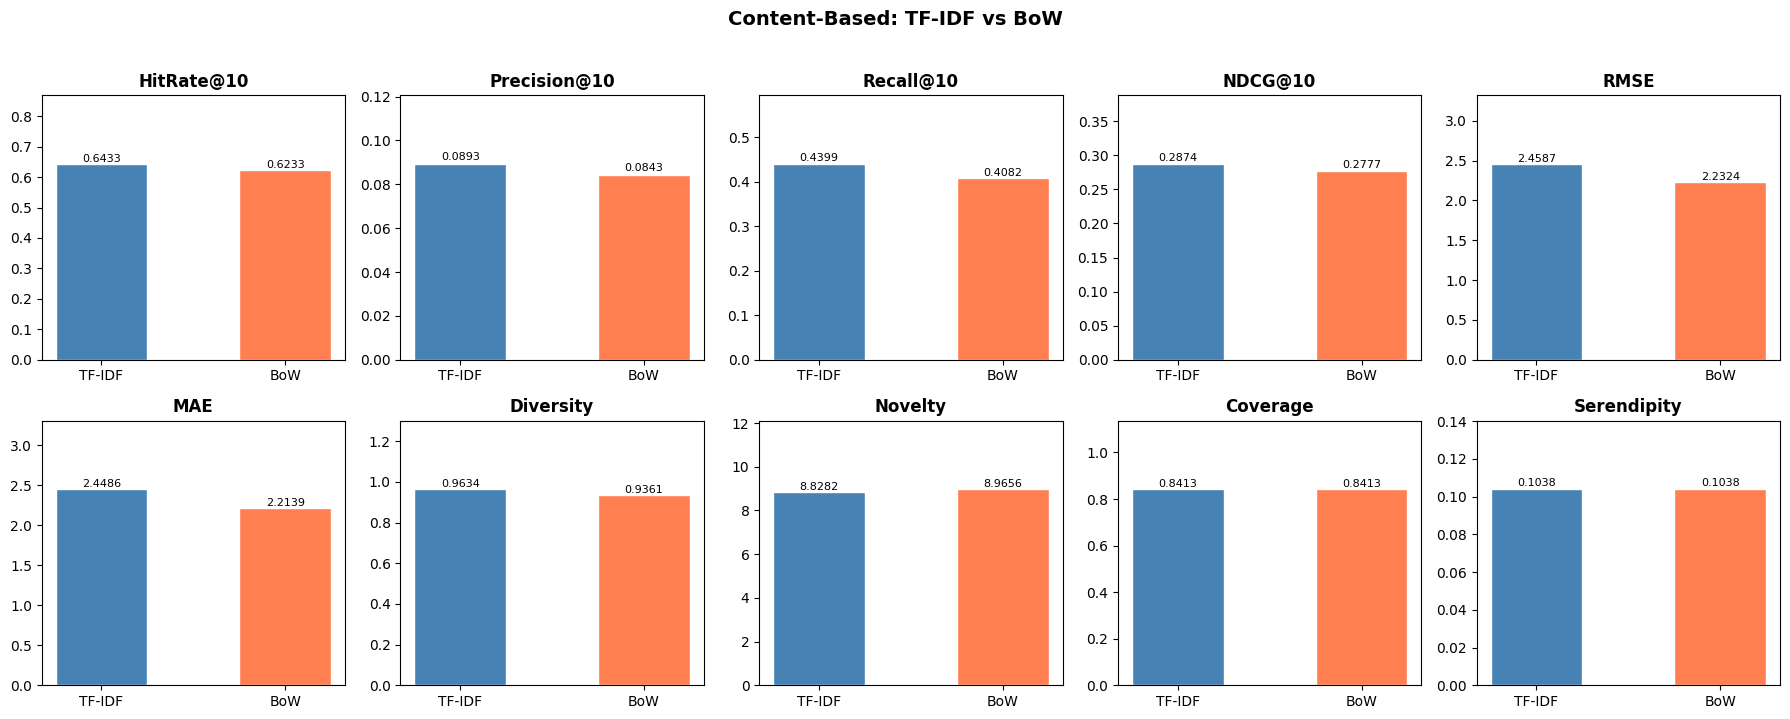

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

metrics = list(results_cb.columns)
colors = ['steelblue', 'coral']

for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(results_cb.index, results_cb[metric], color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontweight='bold')

    ymax = results_cb[metric].max()
    ax.set_ylim(0, ymax * 1.35 + 1e-6 if ymax > 0 else 1)

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{bar.get_height():.4f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.suptitle('Content-Based: TF-IDF vs BoW', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_tfidf_vs_bow_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

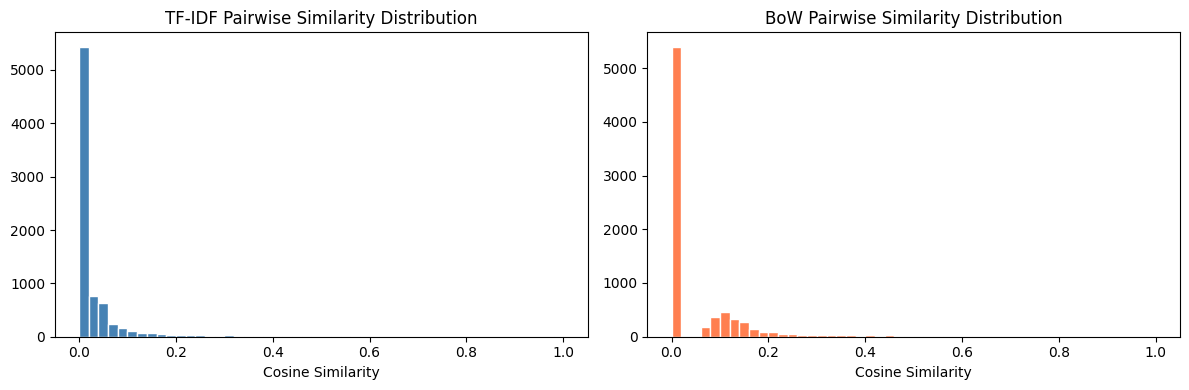

TF-IDF mean sim: 0.0308  std: 0.0811
BoW    mean sim: 0.0568  std: 0.1137


In [17]:
tfidf_sims = tfidf_cos[np.triu_indices_from(tfidf_cos, k=1)]
bow_sims = bow_cos[np.triu_indices_from(bow_cos, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(tfidf_sims, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('TF-IDF Pairwise Similarity Distribution')
axes[0].set_xlabel('Cosine Similarity')

axes[1].hist(bow_sims, bins=50, color='coral', edgecolor='white')
axes[1].set_title('BoW Pairwise Similarity Distribution')
axes[1].set_xlabel('Cosine Similarity')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_similarity_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"TF-IDF mean sim: {tfidf_sims.mean():.4f}  std: {tfidf_sims.std():.4f}")
print(f"BoW    mean sim: {bow_sims.mean():.4f}  std: {bow_sims.std():.4f}")

## 8. Similarity Score Distribution

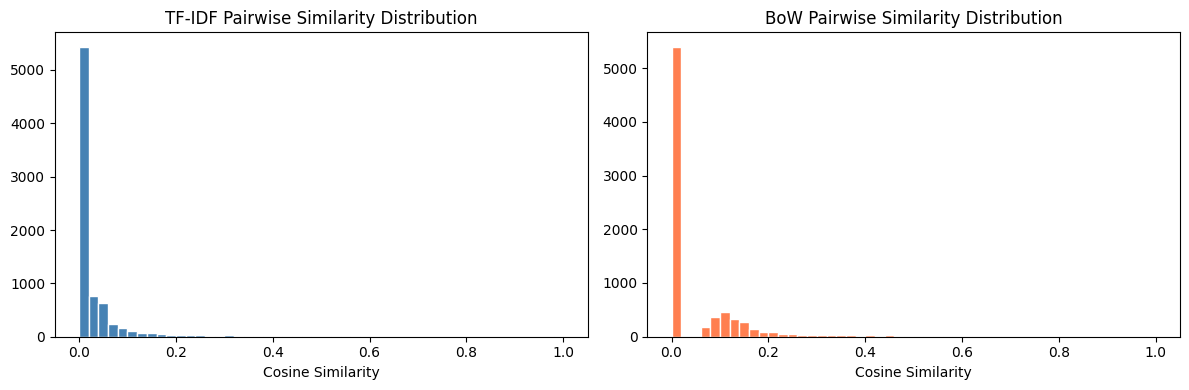

TF-IDF mean sim: 0.0308  std: 0.0811
BoW    mean sim: 0.0568  std: 0.1137


In [18]:
tfidf_sims = tfidf_cos[np.triu_indices_from(tfidf_cos, k=1)]
bow_sims   = bow_cos[np.triu_indices_from(bow_cos, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(tfidf_sims, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('TF-IDF Pairwise Similarity Distribution')
axes[0].set_xlabel('Cosine Similarity')

axes[1].hist(bow_sims, bins=50, color='coral', edgecolor='white')
axes[1].set_title('BoW Pairwise Similarity Distribution')
axes[1].set_xlabel('Cosine Similarity')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_similarity_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"TF-IDF mean sim: {tfidf_sims.mean():.4f}  std: {tfidf_sims.std():.4f}")
print(f"BoW    mean sim: {bow_sims.mean():.4f}  std: {bow_sims.std():.4f}")


## 9. Save Artefacts for Notebook 4

In [19]:
with open(MODELS_DIR / 'tfidf_cos_df.pkl', 'wb') as f:
    pickle.dump(tfidf_cos_df, f)

with open(MODELS_DIR / 'bow_cos_df.pkl', 'wb') as f:
    pickle.dump(bow_cos_df, f)

with open(MODELS_DIR / 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vec, f)

with open(MODELS_DIR / 'bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow_vec, f)

results_cb.to_csv(RESULTS_DIR / 'results_content_based_before.csv')

print("Saved models  →", MODELS_DIR)
print("  tfidf_cos_df.pkl")
print("  bow_cos_df.pkl")
print("  tfidf_vectorizer.pkl")
print("  bow_vectorizer.pkl")
print("Saved results →", RESULTS_DIR / 'results_content_based_before.csv')

Saved models  → models/content_based
  tfidf_cos_df.pkl
  bow_cos_df.pkl
  tfidf_vectorizer.pkl
  bow_vectorizer.pkl
Saved results → results/results_content_based_before.csv
